### Lab – Physics-Informed Neural Networks (PINN): ODE and high frequencies

During this lab session, we will:

- Implement a simple PINN for a 1D **ordinary differential equation** (ODE).
- Understand how to use `torch.autograd` to calculate the necessary derivatives.
- Construct a **multi-term cost function** (ODE + boundary conditions).
- Highlight the difficulty networks have in representing **high-frequency solutions** (spectral bias).
- Introduce the concept of Fourier features to improve the representation of high frequencies.


## Part 1 – PINN for a 1D ODE

Consider the following ODE on the domain $\Omega = [-1,1]$ :

$$
\frac{d^2 u(x)}{dx^2} - u(x) = f(x), \quad f(x) = -(\pi^2 + 1)\sin(\pi x),
$$
with the boundary conditions :
$$
u(-1) = 0, \quad u(1) = 0.
$$

We can show that the exact solution is :
$$
u(x) = \sin(\pi x).
$$

---

**Question 1 :**
In one or two sentences, explain the principle of a **Physics-Informed Neural Network** : how is physics integrated in the learning process ?

**Your answer:** Physics is integrated through labels given to data.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad

SEED = 1

# CUDA ?
cuda = torch.cuda.is_available()
device = torch.device("cuda" if cuda else "cpu")

# Reproductibility
torch.manual_seed(SEED)
if cuda:
    torch.cuda.manual_seed(SEED)
    print("Cuda in use")
else:
    print("CPU only")

Cuda in use


### 1.2 Neural network 

We use a simple fully-connected neural network :

- Entry size : 1 : $x$,
- Several hidden layers with a `Tanh` activation functon,
- Output size : 1 : $u(x)$, with **linear activation**.

---
**Question 2 :**  
Explain which kind of activation functions can be used for approximating PDEs. 
**Your answer:** Tanh, ReLu, GELU.

**Question 3 :**  
Why do we use a  **linear activation function** for the network output
(and not 'Tanh' as in the hidden layers) in order to approximate $u(x)$ ?

**Your answer:** Because tanh and sigmoïde will bound output between 0 and 1 and we want all value


In [3]:
class PINN1D(nn.Module):
    """Simple fully-connected network for a 1D PINN."""
    def __init__(self, n_hidden: int = 25, n_layers: int = 1):
        super().__init__()
        self.input_layer = nn.Linear(1, n_hidden)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(n_hidden, n_hidden) for _ in range(n_layers)]
        )
        self.output_layer = nn.Linear(n_hidden, 1)
        self.activation = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        u = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            u = self.activation(layer(u))
        out = self.output_layer(u)
        return out

# Instantiate a default model
model_1d = PINN1D(n_hidden=25, n_layers=1).to(device)
print(model_1d)

PINN1D(
  (input_layer): Linear(in_features=1, out_features=25, bias=True)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=25, out_features=25, bias=True)
  )
  (output_layer): Linear(in_features=25, out_features=1, bias=True)
  (activation): Tanh()
)


### 1.3 Data formatting

We construct:

- points $x_i$ evenly spaced in $[-1,1]$,
- the source term $f(x_i)$,
- the **boundary** points for the boundary conditions.

We then transform this data into **PyTorch tensors** and activate `requires_grad`
so that we can automatically calculate the derivatives of $u(x)$.

---

**Question 4:**  
Why must the `requires_grad` attribute of `tensor_x` be set to `True`
before training the PINN?

**Your answer:** For autograd to record operation on this tensor because on one time we will need grad of `tensor_x` too


In [4]:
# Number of interior points
nx = 30

# Training points in [-1, 1]
x_np = np.linspace(-1.0, 1.0, nx)

# Source term f(x) = -(pi^2 + 1) sin(pi x)
f_np = -(np.pi**2 + 1.0) * np.sin(np.pi * x_np)

# Boundary conditions: u(-1) = u(1) = 0
x_bc_np = np.array([-1.0, 1.0])
u_bc_np = np.array([0.0, 0.0])

# Convert to PyTorch tensors
tensor_x = torch.from_numpy(x_np).float().reshape(-1, 1)
tensor_f = torch.from_numpy(f_np).float().reshape(-1, 1)
tensor_x_bc = torch.from_numpy(x_bc_np).float().reshape(-1, 1)
tensor_u_bc = torch.from_numpy(u_bc_np).float().reshape(-1, 1)

# We need to differentiate u(x) with respect to x
tensor_x.requires_grad = True

# Send to device
tensor_x = tensor_x.to(device)
tensor_f = tensor_f.to(device)
tensor_x_bc = tensor_x_bc.to(device)
tensor_u_bc = tensor_u_bc.to(device)

### 1.4 Loss functions and training loop setup

We define:

- an optimiser (e.g. Adam),
- a loss for the ODE (internal residual),
- a loss for the boundary conditions,
- lists to track the evolution of losses over iterations.

In [5]:
# Training hyperparameters
epochs = 1500
learning_rate = 5e-4

# Optimizer
optimizer = optim.Adam(model_1d.parameters(), lr=learning_rate)

# Loss functions
loss_interior_fn = nn.MSELoss()
loss_bc_fn = nn.MSELoss()

# Lists to track the evolution of losses
losses_total = []
losses_bc = []
losses_interior = []

**Question 5:**  
Why do we pass the parameters `create_graph=True` and `allow_unused=True` to the function
`torch.autograd.grad` when calculating the derivatives of $u(x)$?

Example:  
```python
u_x = grad(flat(u_pred), tensor_x, create_graph=True, allow_unused=True)[0]
```
**Your answer:** `create_graph=True` is here to retain graph to be used in the second derivative order. `allow_unused=True` is here to not be bothered by pytorch.



In [7]:

def flat(x: torch.Tensor):
    """Convert a tensor (N, 1) into a list of scalars for autograd.grad."""
    m = x.shape[0]
    return [x[i] for i in range(m)]

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # --- Boundary condition loss ---
    #TODO: compute the predicted values and loss at the boundary points
    bc_pred = model_1d(tensor_x_bc)
    loss_bc = loss_bc_fn(bc_pred, tensor_u_bc)
    losses_bc.append(loss_bc.detach().cpu().item())

    # --- ODE loss ---
    # TODO: compute the predicted values at the interior points
    u_pred = model_1d(tensor_x)
    
    #TODO: First derivative u_x
    u_x = grad(flat(u_pred), tensor_x, create_graph=True, allow_unused=True)[0]

    #TODO: Second derivative u_xx
    u_xx = grad(flat(u_x), tensor_x, create_graph=True, allow_unused=True)[0]

    # ODE residual: u''(x) - u(x) - f(x) = 0
    residual = u_xx - u_pred - tensor_f

    # Force the residual to be close to 0
    zeros = torch.zeros_like(residual)
    loss_interior = loss_interior_fn(residual, zeros)
    losses_interior.append(loss_interior.detach().cpu().item())

    # Total loss
    loss_total = loss_bc + loss_interior
    losses_total.append(loss_total.detach().cpu().item())

    # Backpropagation
    loss_total.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:5d} | Loss total = {loss_total.item():.4e}")


Epoch   100 | Loss total = 4.1345e+01
Epoch   200 | Loss total = 1.6547e+01
Epoch   300 | Loss total = 9.8967e+00
Epoch   400 | Loss total = 6.7878e+00
Epoch   500 | Loss total = 3.3680e+00
Epoch   600 | Loss total = 1.5134e+00
Epoch   700 | Loss total = 7.4772e-01
Epoch   800 | Loss total = 3.9252e-01
Epoch   900 | Loss total = 2.0010e-01
Epoch  1000 | Loss total = 9.5802e-02
Epoch  1100 | Loss total = 4.3422e-02
Epoch  1200 | Loss total = 1.8598e-02
Epoch  1300 | Loss total = 7.4801e-03
Epoch  1400 | Loss total = 2.9986e-03
Epoch  1500 | Loss total = 1.3315e-03


**Question 6:**  
Why is it useful to **track separately** the evolution of each term of the loss
(for example, the loss on the ODE and that on the boundary conditions),  
when in the end we only minimise the sum `loss_total = loss_bc + loss_interior`?

**Your answer:** it allow us to understand if our model take great account of boundary conditions


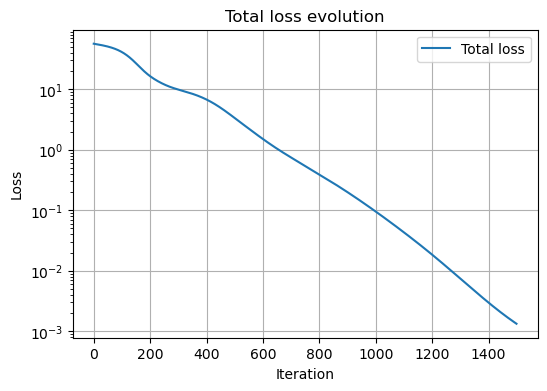

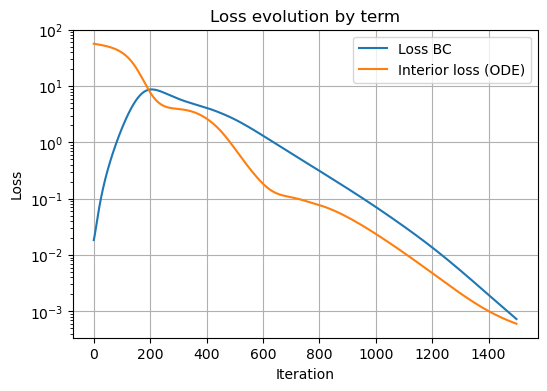

In [8]:
plt.figure(figsize=(6,4))
plt.title("Total loss evolution")
plt.semilogy(losses_total, label="Total loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.title("Loss evolution by term")
plt.semilogy(losses_bc, label="Loss BC")
plt.semilogy(losses_interior, label="Interior loss (ODE)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

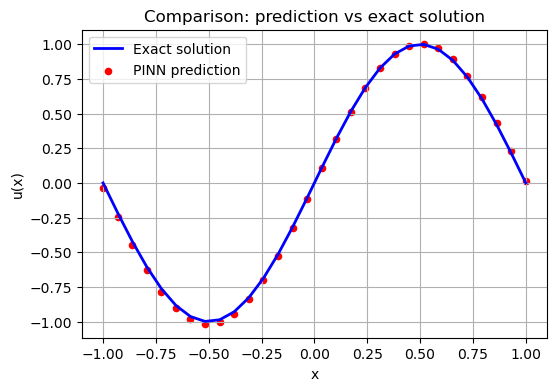

In [9]:
# Analytical solution u(x) = sin(pi x)
x_plot = x_np  # numpy array
u_true = np.sin(np.pi * x_plot)

# Network prediction
with torch.no_grad():
    u_pred_plot = model_1d(
        torch.from_numpy(x_plot).float().reshape(-1,1).to(device)
    ).cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.title("Comparison: prediction vs exact solution")
plt.plot(x_plot, u_true, label="Exact solution", linewidth=2,color='blue')
plt.scatter(x_plot, u_pred_plot, label="PINN prediction", s=20,color='red')
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.show()

### Exercise – Convergence study: PINN vs Finite Differences

We keep the same 1D problem:

$$
\frac{d^2 u}{dx^2} - u(x) = f(x), \quad f(x) = -(\pi^2 + 1)\sin(\pi x), \quad x \in [-1,1],
$$

with $u(-1) = u(1) = 0$ and exact solution $u(x) = \sin(\pi x)$.

The goal is to compare how the approximation error decreases as the number of discretization/collocation points $N$ increases, for two methods:

1. **Finite differences (FD):** classical second-order central scheme,
2. **PINN:** the neural network trained above, retrained for each value of $N$.

---

**Question 7:**
For the finite difference method using second-order central differences, what is the expected order of convergence with respect to the mesh size $h = 2/N$?

**Your answer:** $O(N^2)$

#### Part A – Finite difference solver

Implement a finite difference solver for the 1D problem using second-order central differences.

For interior points $x_1, \dots, x_{N-1}$ with spacing $h = 2/N$:

$$
\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} - u_i = f(x_i)
$$

This gives a tridiagonal system $A \mathbf{u} = \mathbf{b}$.

In [10]:
def solve_fd(nx):
    """
    Solve u''(x) - u(x) = f(x) on [-1,1] with u(-1)=u(1)=0
    using second-order central finite differences.

    Parameters
    ----------
    nx : int
        Number of intervals (nx+1 grid points).

    Returns
    -------
    x : ndarray of shape (nx+1,)
    u : ndarray of shape (nx+1,)
    """
    x = np.linspace(-1, 1, nx + 1)
    h = 2.0 / nx

    # Number of interior unknowns
    N_int = nx - 1

    # Tridiagonal matrix: (1/h^2) on off-diag, (-2/h^2 - 1) on diag
    diag_main = (-2.0 / h**2 - 1.0) * np.ones(N_int)
    diag_off  = ( 1.0 / h**2)        * np.ones(N_int - 1)
    A = np.diag(diag_main) + np.diag(diag_off, 1) + np.diag(diag_off, -1)

    # Right-hand side at interior points
    f_int = -(np.pi**2 + 1.0) * np.sin(np.pi * x[1:-1])

    # Solve
    u_int = np.linalg.solve(A, f_int)

    # Assemble full solution (BCs = 0)
    u_full = np.zeros(nx + 1)
    u_full[1:-1] = u_int
    return x, u_full

# Quick test
x_test, u_test = solve_fd(50)
u_exact_test = np.sin(np.pi * x_test)
print(f"FD test (N=50): L2 error = {np.sqrt(np.mean((u_test - u_exact_test)**2)):.4e}")

FD test (N=50): L2 error = 8.3714e-04


#### Part B – PINN convergence study

Wrap the PINN training into a function that takes the number of collocation points as input, trains the network, and returns the $L^2$ error evaluated on a fine reference grid.

**Question 8:**
Unlike finite differences, the PINN error depends on the network approximation as well as on the optimization process (number of epochs, learning rate, random initialization). How does this affect a fair comparison with FD?

**Your answer:** For non uniform segmentation the FD can be less accurate in different points.

In [11]:
def train_pinn_convergence(n_colloc, epochs=2000, lr=5e-4, n_hidden=25, n_layers=1, seed=42):
    """
    Train a PINN with n_colloc collocation points and return the L2 error.
    The error is measured on a fine grid of 500 points.
    """
    torch.manual_seed(seed)

    model = PINN1D(n_hidden=n_hidden, n_layers=n_layers).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    # Collocation points
    x_col = np.linspace(-1.0, 1.0, n_colloc)
    f_col = -(np.pi**2 + 1.0) * np.sin(np.pi * x_col)

    # Boundary conditions
    x_bc = np.array([-1.0, 1.0])
    u_bc = np.array([ 0.0,  0.0])

    t_x   = torch.from_numpy(x_col).float().reshape(-1, 1).to(device)
    t_x.requires_grad = True
    t_f   = torch.from_numpy(f_col).float().reshape(-1, 1).to(device)
    t_xbc = torch.from_numpy(x_bc).float().reshape(-1, 1).to(device)
    t_ubc = torch.from_numpy(u_bc).float().reshape(-1, 1).to(device)

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # BC loss
        loss_bc = mse(model(t_xbc), t_ubc)

        # PDE residual loss
        u_pred = model(t_x)
        u_x  = grad(flat(u_pred), t_x, create_graph=True, allow_unused=True)[0]
        u_xx = grad(flat(u_x),    t_x, create_graph=True, allow_unused=True)[0]
        residual = u_xx - u_pred - t_f
        loss_int = mse(residual, torch.zeros_like(residual))

        loss = loss_bc + loss_int
        loss.backward()
        optimizer.step()

    # Evaluate error on fine grid
    x_eval = np.linspace(-1.0, 1.0, 500)
    u_exact = np.sin(np.pi * x_eval)
    with torch.no_grad():
        u_pred_eval = model(
            torch.from_numpy(x_eval).float().reshape(-1, 1).to(device)
        ).cpu().numpy().flatten()

    l2_error = np.sqrt(np.mean((u_pred_eval - u_exact)**2))
    return l2_error

#### Part C – Comparison

Run both methods for increasing values of $N$ and plot the $L^2$ error on a log-log scale.

**Question 9:**
Compare the convergence curves. What do you observe? In which regime (few points vs many points) does each method perform better? What are the advantages and limitations of each approach?

**Question 10:**
What is convergence rate of both approaches wrt. number of increasing discretization points?

**Your answer:** 

Q9: for FD, the convergence curve decrease logarithmicly with N growing however for PINN it decrease fast to be minimum in N = 10 and then it went up to a plate. So for N low PINN is better and for N high FD will be a lot better

Q10: It is the norm of the L2 error

In [12]:
nx_values = [5, 10, 20, 40, 80, 160]

# --- Finite Differences ---
fd_errors = []
for nx_val in nx_values:
    x_fd, u_fd = solve_fd(nx_val)
    u_exact_fd = np.sin(np.pi * x_fd)
    err = np.sqrt(np.mean((u_fd - u_exact_fd)**2))
    fd_errors.append(err)
    print(f"FD   N={nx_val:4d}  ->  L2 error = {err:.4e}")

print()

# --- PINN ---
pinn_errors = []
for nx_val in nx_values:
    err = train_pinn_convergence(nx_val, epochs=2000)
    pinn_errors.append(err)
    print(f"PINN N={nx_val:4d}  ->  L2 error = {err:.4e}")

FD   N=   5  ->  L2 error = 8.2540e-02
FD   N=  10  ->  L2 error = 2.0480e-02
FD   N=  20  ->  L2 error = 5.1750e-03
FD   N=  40  ->  L2 error = 1.3053e-03
FD   N=  80  ->  L2 error = 3.2808e-04
FD   N= 160  ->  L2 error = 8.2259e-05

PINN N=   5  ->  L2 error = 9.6443e-02
PINN N=  10  ->  L2 error = 1.6041e-03
PINN N=  20  ->  L2 error = 5.0663e-03
PINN N=  40  ->  L2 error = 5.6343e-03
PINN N=  80  ->  L2 error = 6.2595e-03
PINN N= 160  ->  L2 error = 6.5816e-03


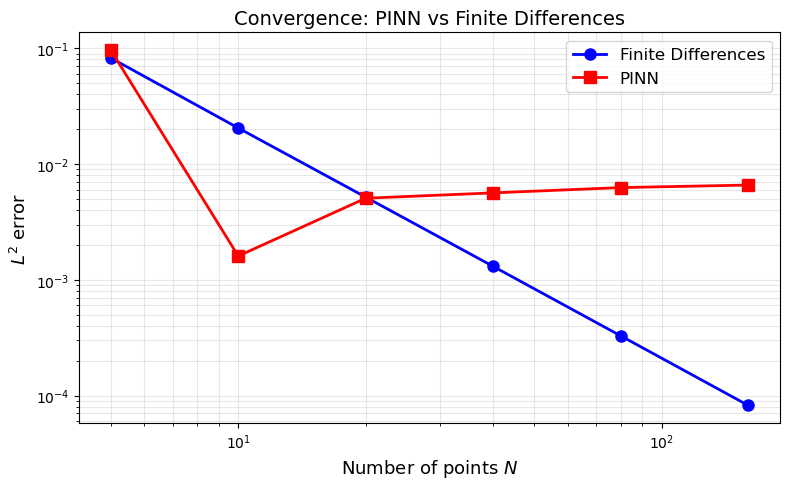

In [13]:
plt.figure(figsize=(8, 5))
plt.loglog(nx_values, fd_errors, 'bo-', linewidth=2, markersize=8, label='Finite Differences')
plt.loglog(nx_values, pinn_errors, 'rs-', linewidth=2, markersize=8, label='PINN')

# Reference slope O(N^{-2}) for second-order FD
nx_arr = np.array(nx_values, dtype=float)
ref = fd_errors[0] * (nx_arr / nx_arr[0])**(-2)

plt.xlabel('Number of points $N$', fontsize=13)
plt.ylabel('$L^2$ error', fontsize=13)
plt.title('Convergence: PINN vs Finite Differences', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise - 1D Poisson PDE with an $\alpha$ parameter


Consider:

$$
-\frac{d^2 u}{dx^2} = f(x)
$$

on $\Omega = [-1,1]$, with solution

$$
u(x) = \sin(\alpha x).
$$

1. Express $f(x)$ as a function of $\alpha$.
2. Adapt the 1D PINN for this problem.
3. Vary $\alpha$ between 0.5 and 15 and observe the impact on the quality of the solution.

**Your answer:** 

1. $f(x) = \alpha^2*\sin(\alpha x)$


## Part 2 – PINN, frequencies and Fourier features in 2D

We now consider a PDE on $\Omega = [0,\pi] \times [0,\pi]$:

$$
- \frac{\partial^2 u}{\partial x^2} - \frac{\partial^2 u}{\partial y^2} = f(x,y),
$$

with the exact solution:

$$
u(x,y) = \cos(\alpha \pi x + \beta \pi y),
$$

where $\alpha,\beta \in \mathbb{N}$ control the **frequencies**.

We want to train a PINN for different values of $(\alpha,\beta)$ and observe
the increasing difficulty of the network as the frequencies increase.

In [14]:
class PINN2D(nn.Module):
    """Simple fully-connected network for a 2D PINN (x, y) -> u(x,y)."""
    def __init__(self, n_hidden: int = 40, n_layers: int = 3):
        super().__init__()
        self.input_layer = nn.Linear(2, n_hidden)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(n_hidden, n_hidden) for _ in range(n_layers)]
        )
        self.output_layer = nn.Linear(n_hidden, 1)
        self.activation = nn.Tanh()

    def forward(self, xy: torch.Tensor) -> torch.Tensor:
        u = self.activation(self.input_layer(xy))
        for layer in self.hidden_layers:
            u = self.activation(layer(u))
        out = self.output_layer(u)
        return out

In [ ]:
# Discretization parameters
n_x = 25
n_y = 25

# Frequency parameters (user-adjustable)
alpha = 2
beta = 2

# Regular grid on [0, pi] x [0, pi]
x_lin = np.linspace(0.0, np.pi, n_x)
y_lin = np.linspace(0.0, np.pi, n_y)
X, Y = np.meshgrid(x_lin, y_lin)

# Flatten the grids to obtain a list of points (N, 2)
xy_np = np.stack([X.ravel(), Y.ravel()], axis=1)

# Exact solution u(x,y) = cos(alpha*pi*x + beta*pi*y)
def u_exact(xy_tensor: torch.Tensor, alpha_val: int, beta_val: int) -> torch.Tensor:
    x = xy_tensor[:, 0:1]
    y = xy_tensor[:, 1:2]
    return torch.cos(alpha_val * np.pi * x + beta_val * np.pi * y)

# Source term f(x,y) = (alpha^2 + beta^2) * pi^2 * cos(...)
def f_source(xy_tensor: torch.Tensor, alpha_val: int, beta_val: int) -> torch.Tensor:
    u = u_exact(xy_tensor, alpha_val, beta_val)
    return (alpha_val**2 + beta_val**2) * (np.pi**2) * u



In [19]:
# Make sure autograd is enabled
torch.set_grad_enabled(True)

# Regenerate the xy tensor from xy_np
xy = torch.from_numpy(xy_np).float().to(device)
xy.requires_grad_(True)  # IMPORTANT: we need ∂u/∂x, ∂u/∂y, etc.

# Source term f(x,y), detached from graph (no gradient w.r.t. f)
f_xy = f_source(xy, alpha, beta).detach()

# --- Build a boundary mask for the BCs ---
x_coords = xy[:, 0]
y_coords = xy[:, 1]
eps = 1e-7

# Boundary points: x=0, x=pi, y=0, or y=pi
mask_bc = (
    (torch.isclose(x_coords, torch.tensor(0.0, device=device), atol=eps)) |
    (torch.isclose(x_coords, torch.tensor(np.pi, device=device), atol=eps)) |
    (torch.isclose(y_coords, torch.tensor(0.0, device=device), atol=eps)) |
    (torch.isclose(y_coords, torch.tensor(np.pi, device=device), atol=eps))
)

# Interior indices (complement of boundary)
mask_interior = ~mask_bc

# New 2D model and optimizer — reset seed for reproducible initialization
torch.manual_seed(SEED)
model_2d = PINN2D(n_hidden=40, n_layers=3).to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=5e-4)

loss_pde_fn = nn.MSELoss()
loss_bc_fn = nn.MSELoss()
lambda_bc = 10.0  # weight for boundary conditions

epochs_2d = 10000
losses_2d_total = []
losses_2d_pde = []
losses_2d_bc = []

for epoch in range(1, epochs_2d + 1):
    optimizer_2d.zero_grad()

    # -----------------------------
    # 1) Predict u(x,y) on ALL points
    # -----------------------------
    u_pred = model_2d(xy)          # (N,1)

    # Separate boundary and interior values
    u_pred_bc = u_pred[mask_bc]           # (N_bc, 1)
    u_pred_interior = u_pred[mask_interior]  # (N_int, 1)

    xy_bc = xy[mask_bc]                   # (N_bc, 2)

    # -----------------------------
    # 2) Boundary condition loss
    #    u(x,y) = u_exact(x,y) on the boundary
    # -----------------------------
    with torch.no_grad():
        u_true_bc = u_exact(xy_bc, alpha, beta)
    loss_bc = loss_bc_fn(u_pred_bc, u_true_bc)

    # -----------------------------
    # 3) PDE loss (interior)
    #    Differentiate with respect to xy
    #    then restrict to interior points using the mask.
    # -----------------------------
    #TODO:: Compute the derivatives u_xx and u_yy
    u_x = grad(flat(u_pred), xy, create_graph=True, allow_unused=True)[0][:, 0:1]
    u_y = grad(flat(u_pred), xy, create_graph=True, allow_unused=True)[0][:, 1:2]
    u_xx = grad(flat(u_x), xy, create_graph=True, allow_unused=True)[0][:, 0:1]
    u_yy = grad(flat(u_y), xy, create_graph=True, allow_unused=True)[0][:, 1:2]

    # TODO: Restrict to interior points using mask
    u_xx_int = u_xx[mask_interior]
    u_yy_int = u_yy[mask_interior]
    f_int = f_xy[mask_interior]

    # TODO:: Compute PDE residual: -\Delta u - f(x,y) = 0
    residual = - (u_xx_int + u_yy_int) - f_int
    zeros = torch.zeros_like(residual)


    loss_pde = loss_pde_fn(residual, zeros)

    # -----------------------------
    # 4) Total loss = PDE + BC
    # -----------------------------
    loss_total = loss_pde + lambda_bc * loss_bc

    losses_2d_total.append(loss_total.detach().cpu().item())
    losses_2d_pde.append(loss_pde.detach().cpu().item())
    losses_2d_bc.append(loss_bc.detach().cpu().item())

    # -----------------------------
    # 5) Backprop & update
    # -----------------------------
    loss_total.backward()
    optimizer_2d.step()

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss tot = {loss_total.item():.4e} | "
            f"PDE = {loss_pde.item():.4e} | "
            f"BC = {loss_bc.item():.4e}"
        )

Epoch   500 | Loss tot = 1.3780e+01 | PDE = 1.0119e+01 | BC = 3.6609e-01
Epoch  1000 | Loss tot = 6.1196e-01 | PDE = 5.3802e-01 | BC = 7.3942e-03
Epoch  1500 | Loss tot = 1.6608e-01 | PDE = 1.4532e-01 | BC = 2.0760e-03
Epoch  2000 | Loss tot = 1.2568e-02 | PDE = 8.9190e-03 | BC = 3.6491e-04
Epoch  2500 | Loss tot = 7.6689e-03 | PDE = 5.4072e-03 | BC = 2.2617e-04
Epoch  3000 | Loss tot = 5.2717e-03 | PDE = 3.6975e-03 | BC = 1.5742e-04
Epoch  3500 | Loss tot = 3.7488e-03 | PDE = 2.5648e-03 | BC = 1.1840e-04
Epoch  4000 | Loss tot = 3.0484e-03 | PDE = 2.1486e-03 | BC = 8.9986e-05
Epoch  4500 | Loss tot = 2.1670e-03 | PDE = 1.3889e-03 | BC = 7.7816e-05
Epoch  5000 | Loss tot = 1.7721e-03 | PDE = 1.0996e-03 | BC = 6.7251e-05
Epoch  5500 | Loss tot = 1.4925e-03 | PDE = 9.0103e-04 | BC = 5.9146e-05
Epoch  6000 | Loss tot = 2.4908e-02 | PDE = 2.3516e-02 | BC = 1.3927e-04
Epoch  6500 | Loss tot = 1.1142e-03 | PDE = 6.3181e-04 | BC = 4.8242e-05
Epoch  7000 | Loss tot = 9.9026e-04 | PDE = 5.5209e

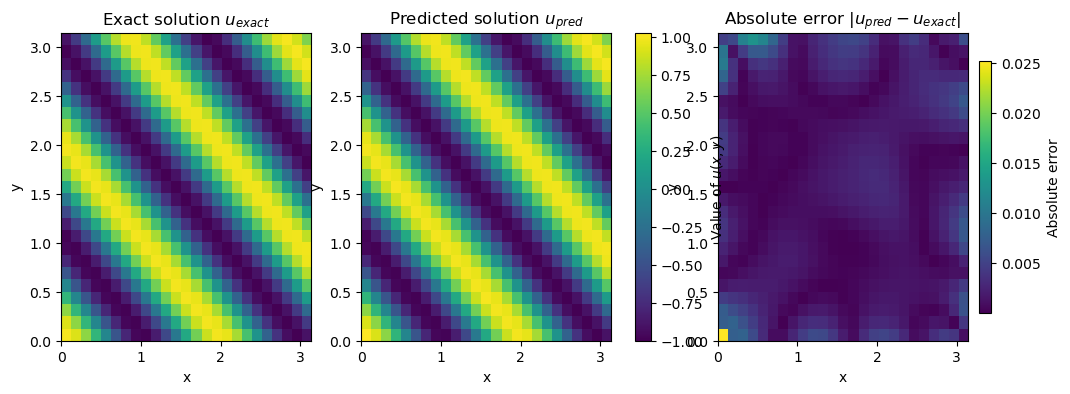

In [20]:
with torch.no_grad():
    u_true_xy = u_exact(xy, alpha, beta).cpu().numpy().reshape(n_y, n_x)
    u_pred_xy = model_2d(xy).cpu().numpy().reshape(n_y, n_x)
    err_xy = np.abs(u_pred_xy - u_true_xy)

# Same color bounds for u_true and u_pred
vmin = min(u_true_xy.min(), u_pred_xy.min())
vmax = max(u_true_xy.max(), u_pred_xy.max())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) u_exact
im0 = axes[0].imshow(
    u_true_xy,
    extent=[0, np.pi, 0, np.pi],
    origin="lower",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Exact solution $u_{{exact}}$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# 2) u_pred
im1 = axes[1].imshow(
    u_pred_xy,
    extent=[0, np.pi, 0, np.pi],
    origin="lower",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("Predicted solution $u_{{pred}}$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Shared colorbar for u_exact and u_pred
cbar_u = fig.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)
cbar_u.set_label("Value of $u(x,y)$")

# 3) Absolute error
im2 = axes[2].imshow(
    err_xy,
    extent=[0, np.pi, 0, np.pi],
    origin="lower",
    aspect="auto",
)
axes[2].set_title("Absolute error $|u_{pred} - u_{exact}|$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

cbar_err = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar_err.set_label("Absolute error")
plt.show()

### Exercise – Influence of $(\alpha,\beta)$

Keeping the same network architecture:

1. Vary $(\alpha,\beta)$ among, for example:  
   $(1,1), (2,2), (5,5)$.
2. For each pair, retrain the 2D PINN and visualise the error.

**Question 11:**  
What do you notice when the frequencies $(\alpha,\beta)$ increase?  
How does this illustrate the phenomenon of **spectral bias** in neural networks?

**Your answer:** More the high frequency is taken more time it takes to train model

*(See: https://arxiv.org/abs/1806.08734 and https://arxiv.org/pdf/2012.10047)*

## BONUS

### 2D networks with **Fourier features**

In this section, we modify the PINN input to give it a richer frequency representation.  
Instead of sending $(x,y)$ directly into the network, we first apply a **layer of Fourier features**:

$$
z(x,y) =
\big(
\sin(2\pi B z),\ \cos(2\pi B z)
\big),
\quad
\text{with } z = (x/\pi,\ y/\pi) \in [0,1]^2,
$$

where $B \in \mathbb{R}^{n_{\text{features}} \times 2}$ is a matrix whose coefficients are drawn according to a normal distribution
$\mathcal{N}(0,\gamma^2)$.

The idea is the following:

- First, we normalise $(x,y)$ in $[0,1]^2$ (line `xy_scaled = xy / np.pi`).
- We project these coordinates using the random matrix $B$: `proj = 2*np.pi*xy_scaled @ self.B.t()`.
- We then construct the **Fourier features** by concatenating `sin(proj)` and `cos(proj)`:
this vector contains oscillating linear combinations of $x$ and $y$, of various frequencies.
- This vector $[\sin(Bz), \cos(Bz)]$ of dimension $2\,n_{\text{features}}$ is then sent
  to a classic MLP (`input_layer`, `hidden_layers`, `output_layer`).

**Role of parameters:**

- $n_{\text{features}}$: number of random frequencies used.  
  The larger it is, the richer the representation, but the more unstable/costly training can become.
- $\gamma$: standard deviation of the normal distribution for the coefficients of $B$.  
  It controls the range of frequencies explored:  
  - small $\gamma$: rather low frequencies,  
  - large $\gamma$: higher frequencies, potentially more difficult to optimise.

**Why does this help?**

Standard neural networks tend to spontaneously prefer **low frequencies**
(*spectral bias*).  
By projecting $(x,y)$ into a space of sinusoidal functions with random frequencies, we give
the network a basis of already oscillating functions, which helps it approximate
high-frequency solutions (for example when $\alpha,\beta$ are large in
$u(x,y) = \cos(\alpha \pi x + \beta \pi y)$).

---

**Note:**

In the following, we will compare:

- a **standard** 2D PINN (raw $(x,y)$ input),
- a 2D PINN **with Fourier features** (enriched input).

The objective is not necessarily to obtain a perfect loss, but to observe numerically that,
for higher frequencies, the model with Fourier features often manages to better
capture the oscillations than the standard model.


In [21]:
class PINN2D_Fourier(nn.Module):
    """2D PINN with Fourier features as input."""
    def __init__(self, n_hidden: int = 40, n_layers: int = 3, n_features: int = 50, gamma: float = 1.0):
        super().__init__()
        self.n_features = n_features
        self.gamma = gamma

        # Matrix B ∈ R^{n_features x 2} sampled from N(0, gamma^2)
        B_np = np.random.normal(loc=0.0, scale=gamma, size=(n_features, 2)).astype(np.float32)
        B = torch.from_numpy(B_np)
        # We do not want to train B, so we register it as a buffer
        self.register_buffer("B", B)

        # Layer taking [sin(Bz), cos(Bz)] ∈ R^{2 * n_features} as input
        self.input_layer = nn.Linear(2 * n_features, n_hidden)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(n_hidden, n_hidden) for _ in range(n_layers)]
        )
        self.output_layer = nn.Linear(n_hidden, 1)
        self.activation = nn.Tanh()

    def fourier_features(self, xy: torch.Tensor) -> torch.Tensor:
        """
        xy : (N,2) with x,y ∈ [0, π]
        Normalize to [0,1]^2 then project using B.
        """
        xy_scaled = xy / np.pi          # now in [0,1]^2
        proj = np.pi*2*xy_scaled @ self.B.t()   
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)

    def forward(self, xy: torch.Tensor) -> torch.Tensor:
        z = self.fourier_features(xy)
        u = self.activation(self.input_layer(z))
        for layer in self.hidden_layers:
            u = self.activation(layer(u))
        out = self.output_layer(u)
        return out

In [ ]:
gamma = 3       # écart-type pour la loi normale de B 
n_features = 50   # nombre de fréquences 

model_2d_fourier = PINN2D_Fourier(
    n_hidden=40,
    n_layers=3,
    n_features=n_features,
    gamma=gamma
).to(device)

optimizer_2d_fourier = optim.Adam(model_2d_fourier.parameters(), lr=5e-4)

loss_pde_fn_fourier = nn.MSELoss()
loss_bc_fn_fourier = nn.MSELoss()

lambda_bc_fourier = 10.0 

epochs_2d_fourier = 10000
losses_2d_fourier_total = []
losses_2d_fourier_pde = []
losses_2d_fourier_bc = []

for epoch in range(1, epochs_2d_fourier + 1):
    optimizer_2d_fourier.zero_grad()

    # 1) TODO:: Compute the predicted values at all points (inside + boundary)
    u_pred = model_2d_fourier(xy)  # (N,1)

    # Séparation bord / intérieur
    u_pred_bc = u_pred[mask_bc]
    u_pred_interior = u_pred[mask_interior]
    xy_bc = xy[mask_bc]

    # 2) CL de Dirichlet : u = u_exact sur le bord
    with torch.no_grad():
        u_true_bc = u_exact(xy_bc, alpha, beta)
    loss_bc = loss_bc_fn_fourier(u_pred_bc, u_true_bc)

    # 3) TODO:: Compute the PDE residual at interior points: 
    #          First compute the derivatives, then restrict to interior points using the mask,
    #          then compute the residual
    u_x = grad(flat(u_pred), xy, create_graph=True, allow_unused=True)[0][:, 0:1]
    u_y = grad(flat(u_pred), xy, create_graph=True, allow_unused=True)[0][:, 1:2]
    u_xx = grad(flat(u_x), xy, create_graph=True, allow_unused=True)[0][:, 0:1]
    u_yy = grad(flat(u_y), xy, create_graph=True, allow_unused=True)[0][:, 1:2]
    residual = - (u_xx[mask_interior] + u_yy[mask_interior]) - f_xy[mask_interior]

    loss_pde = loss_pde_fn_fourier(residual, zeros)

    # 4) Loss totale
    loss_total = loss_pde + lambda_bc_fourier * loss_bc

    losses_2d_fourier_total.append(loss_total.detach().cpu().item())
    losses_2d_fourier_pde.append(loss_pde.detach().cpu().item())
    losses_2d_fourier_bc.append(loss_bc.detach().cpu().item())

    # 5) Backprop + clipping
    loss_total.backward()
    torch.nn.utils.clip_grad_norm_(model_2d_fourier.parameters(), max_norm=1.0)
    optimizer_2d_fourier.step()

    if epoch % 500 == 0:
        print(
            f"[Fourier] Epoch {epoch:5d} | "
            f"Loss tot = {loss_total.item():.4e} | "
            f"PDE = {loss_pde.item():.4e} | "
            f"BC = {loss_bc.item():.4e}"
        )

[Fourier] Epoch   500 | Loss tot = 9.3394e-01 | PDE = 3.2791e-01 | BC = 6.0603e-02
[Fourier] Epoch  1000 | Loss tot = 2.0608e-01 | PDE = 1.2652e-01 | BC = 7.9562e-03
[Fourier] Epoch  1500 | Loss tot = 1.7904e-01 | PDE = 1.4537e-01 | BC = 3.3668e-03
[Fourier] Epoch  2000 | Loss tot = 1.3345e-01 | PDE = 1.1563e-01 | BC = 1.7813e-03
[Fourier] Epoch  2500 | Loss tot = 1.7634e-01 | PDE = 1.6386e-01 | BC = 1.2483e-03
[Fourier] Epoch  3000 | Loss tot = 1.0511e-01 | PDE = 9.6603e-02 | BC = 8.5109e-04
[Fourier] Epoch  3500 | Loss tot = 1.1798e-01 | PDE = 1.1127e-01 | BC = 6.7163e-04
[Fourier] Epoch  4000 | Loss tot = 8.8573e-02 | PDE = 8.3575e-02 | BC = 4.9980e-04
[Fourier] Epoch  4500 | Loss tot = 3.4048e-01 | PDE = 3.3642e-01 | BC = 4.0619e-04
[Fourier] Epoch  5000 | Loss tot = 8.5514e-02 | PDE = 8.2221e-02 | BC = 3.2933e-04
[Fourier] Epoch  5500 | Loss tot = 8.8738e-02 | PDE = 8.6049e-02 | BC = 2.6896e-04
[Fourier] Epoch  6000 | Loss tot = 8.1194e-02 | PDE = 7.8993e-02 | BC = 2.2013e-04
[Fou

In [ ]:
plt.figure(figsize=(6,4))
plt.semilogy(losses_2d_total, label="Standard - total loss")
plt.semilogy(losses_2d_fourier_total, label="Fourier - total loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Convergence comparison: PINN vs PINN + Fourier features")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
with torch.no_grad():
    u_true_xy = u_exact(xy, alpha, beta).cpu().numpy().reshape(n_y, n_x)
    u_pred_xy_fourier = model_2d_fourier(xy).cpu().numpy().reshape(n_y, n_x)
    err_xy_fourier = np.abs(u_pred_xy_fourier - u_true_xy)

# Same color bounds for u_true and u_pred_fourier
vmin = min(u_true_xy.min(), u_pred_xy_fourier.min())
vmax = max(u_true_xy.max(), u_pred_xy_fourier.max())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) u_exact
im0 = axes[0].imshow(
    u_true_xy,
    extent=[0, np.pi, 0, np.pi],
    origin="lower",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Exact solution $u_{exact}$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# 2) u_pred (Fourier)
im1 = axes[1].imshow(
    u_pred_xy_fourier,
    extent=[0, np.pi, 0, np.pi],
    origin="lower",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("Prediction $u_{pred}$ (Fourier)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Shared colorbar for u_exact and u_pred
cbar_u = fig.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)
cbar_u.set_label("Value of $u(x,y)$")

# 3) Absolute error
im2 = axes[2].imshow(
    err_xy_fourier,
    extent=[0, np.pi, 0, np.pi],
    origin="lower",
    aspect="auto",
)
axes[2].set_title(r"Absolute error $|u_{pred} - u_{exact}|$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

cbar_err = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar_err.set_label("Absolute error")

plt.tight_layout()
plt.show()

### Exercise – Analysis of the contribution of Fourier features

Use the same pairs $(\alpha,\beta)$ as before,
train the network **with** Fourier features, and compare:

- the loss curves,
- the error maps.

**Question 12:**  
What do Fourier features add to the basic network?
How does the quality of the numerical solution change when you increase $\alpha,\beta$?

**Your answer:** *enter your answer here*